# **Data Visualisation**

## Objectives

* Understand how car prices vary across the US market.
* Identify which car features have the strongest relationship with price.
* Explore whether features such as engine size, horsepower, body style and fuel efficiency affect car prices.
* Compare prices between different types and makes of cars.
* Use the findings to support decisions about vehicle design, pricing and market strategy.

## Inputs

* Write down which data or information you need to run the notebook 

## Outputs

* Write here which files, code or artefacts you generate by the end of the notebook 

---

# Change working directory

* The working directory is changed from the 'jupyter_notebook' folder to the project root folder so the cleaned dataset stored in the 'Data' folder can be accessed.

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\liene\\OneDrive\\Documents\\Car Price Analysis\\Car-Prices-Analysis-Project-1\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\liene\\OneDrive\\Documents\\Car Price Analysis\\Car-Prices-Analysis-Project-1'

# Data Visualisation

Import the libraries  needed to explore the data and create visualisations. Pandas, Matplotlib, |Seaborn, Plotly and NumPy will be used throughout this notebook.

## Import Libraries

In [4]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns
import plotly.express as px


# Load Cleaned Dataset

In [5]:
# Load the cleaned dataset
# code references from LMS
df = pd.read_csv("Data/CarPrice_Cleaned.csv")

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romeo giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romeo stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romeo Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100 ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


## Data Visualisations

* **AI Assistance:** ChatGPT is used to help explore suitable visualisation options for this dataset and with wording formulation.  They are based on the buisness requirements. The final visualisations are selected on their relevance to the questions being investegated.

## Matplotlib Visualisations

### Car Price Distribution

This visualisation shows how car prices are distributed throughout the dataset and which price ranges are the most common.

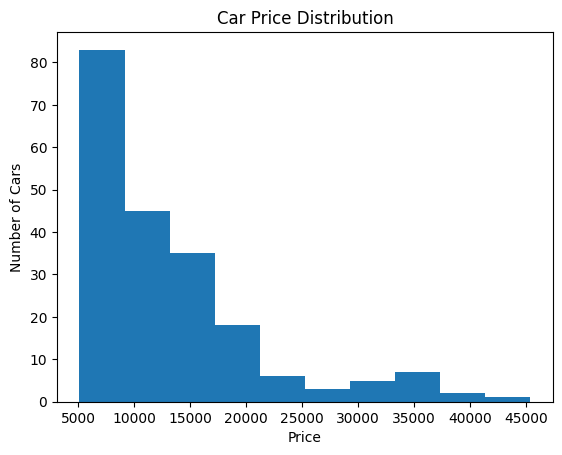

In [7]:
# Create a hisrogram showing the distribution of car prices in the datset.
# This code is referenced from LMS and modified with assistance from ChatGPT
plt.hist(df['price'])

plt.xlabel('Price')
plt.ylabel('Number of Cars')
plt.title('Car Price Distribution')

plt.show()

### Findings

Most cars in this dataset are priced below $15,000. There are fewer cars at higher price. And only small number of cars are in the highest price range.

## Engine Size and Car Price

This visualisation is showing the relationship between engine size and car price.

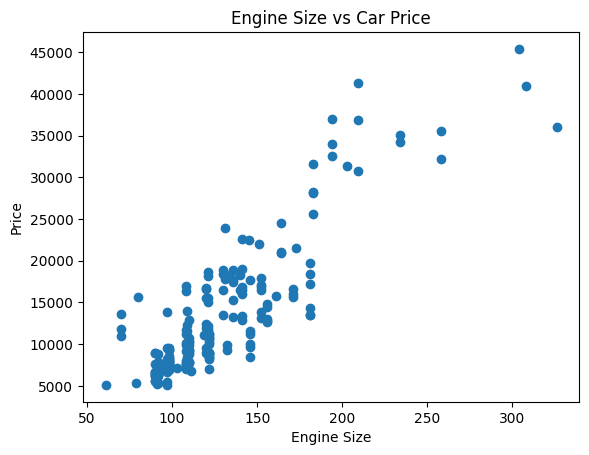

In [8]:
# Showing the relationship between engine size and price.
# Code referanced  from LMS
plt.scatter(df['enginesize'], df['price'])
plt.xlabel('Engine Size')

plt.ylabel('Price')
plt.title('Engine Size vs Car Price')
plt.show()

### Findings 

The scatter plot shows a clear pattern between engine size and price. Cars with larger engines generally have higher prices, which supports the strong relationship found in the data analysis.

### Avarage Price by Car Body Type.

This visualisation compares the avarage car price across different car body types.

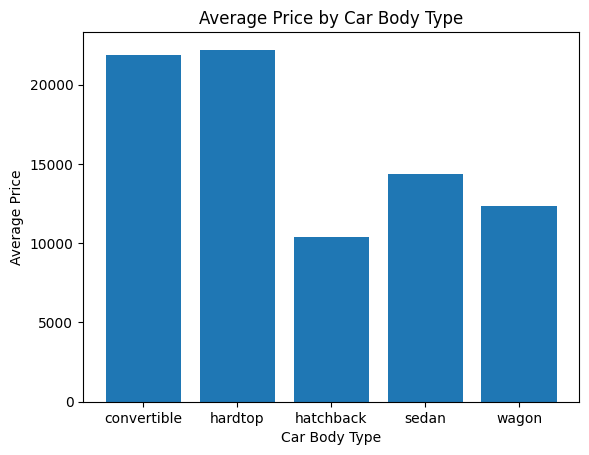

In [9]:
# Calculate the avarage price for each car body type.
# Code referanced from LMS and ChatGPT.
average_price=df.groupby('carbody')['price'].mean()

# Create a bar chart
# Code referanced from LMS and ChatGPT.
plt.bar(average_price.index,average_price.values)

plt.xlabel('Car Body Type')
plt.ylabel('Average Price')
plt.title('Average Price by Car Body Type')

plt.show()

### Findings

Haedtop and convertible cars have the highest average prices, while hatchbacks have the lowest.  
This shows that average car price varies between different body types.

## Seaborn Visualisations

### Car Prices by Fuel Type.

This visualisation compares the distribution of car prices between the different fuel types.

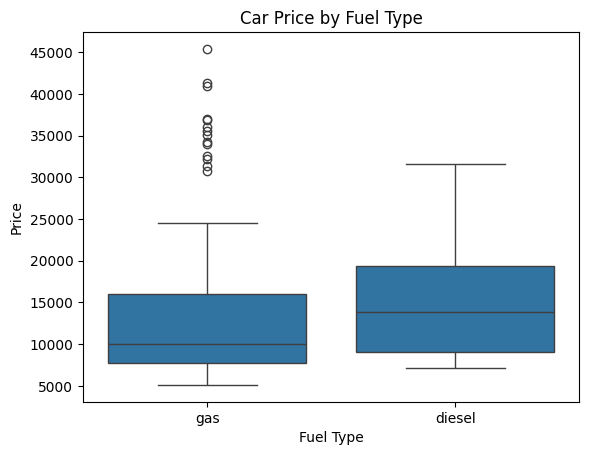

In [10]:
# Compare car prices by fuel type
# Code referenced from LMS with small adjustments.
sns.boxplot(x='fueltype',y='price',data=df)
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.title('Car Price by Fuel Type')
plt.show()

### Findings

Diesel cars generally have higher median price then gas cars. Gas cars also have several high-priced outliers, showing that some gas cars are considerably more expensive than the majority.

### Horsepower and Car Price

This visualisation showsthe relationship between horsepower and car price and help identify the overall trend between them.

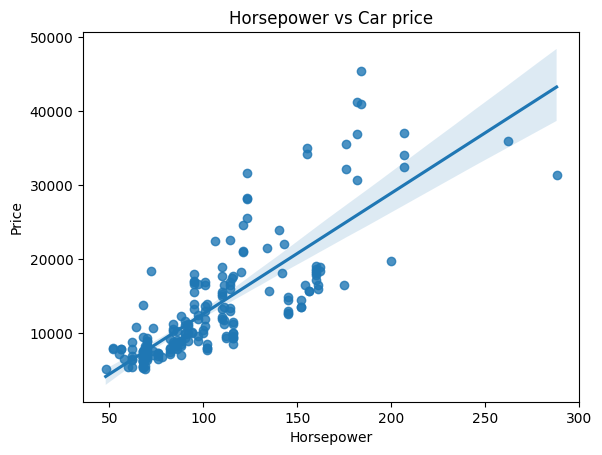

In [11]:
# Show the relationship between horsepoer and price.
# Code referenced from LMS with small adjustments from ChatGPT.
sns.regplot(x='horsepower',y='price',data=df)
plt.xlabel('Horsepower')
plt.ylabel('Price')
plt.title('Horsepower vs Car price')
plt.show()

### Findings

The chart shows a clear positive relationship between horsepower and price. Cars with higher horsepower generally have higher prices, aalthough some cars vary from the overall trend.

### Corealation Between Car Features.

This visualisation compares the correlations between selected numerical car features and price.

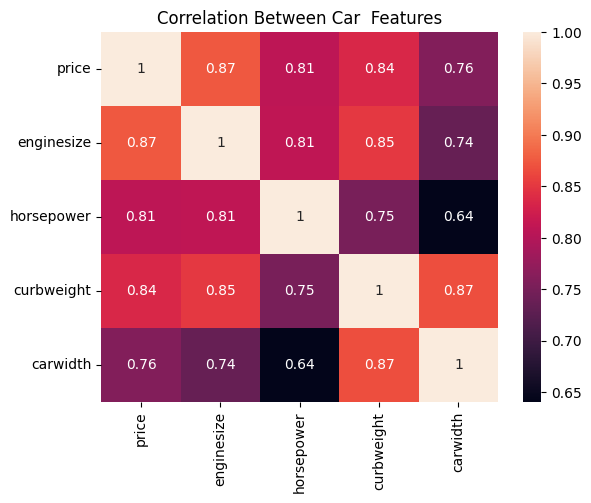

In [12]:
# Create a correlation heatmap for selected numerical features.
# Code referenced from ChatGPT assistance.
correlation = df[['price','enginesize','horsepower','curbweight','carwidth']].corr()
sns.heatmap(correlation,annot=True)
plt.title('Correlation Between Car  Features')
plt.show()

### Findings

Engine size has the strongest relationship with price at 0.87. Curb weight and horsepower also show strong positive relationship with price, while car width shows a slightly weaker relationship.

## Plotly Visualisations

### Highway MPG and Car Price.

This visualisation explores the relationship between highway fuel efficency and car price.

In [13]:
# Show the relationship between highway MPG and price.
# Code referenced from LMS with small adjustments from ChatGPT. 
fig = px.scatter(df, x='highwaympg',y='price', title='Highway MPG vs Car Price')
fig.show()

### Findings

the visualisations shows that cars with higher higway MPG generally have lower price . Cars with lower highway MPG include more of the higher-priced vehicles in the dataset.

### Average Price by Drive Wheel.

This visualisation compares the car price across the different drive wheel types.

In [14]:
# calculate the average price for each drive wheel type.
# Code created with assistance from ChatgpT.
average_drivewheel_price = df.groupby('drivewheel')['price'].mean().reset_index()

# Create interactive bar chart
fig = px.bar(
    average_drivewheel_price,
    x='drivewheel',
    y='price',
    title='Average Price by Drive Wheel'
)
fig.show()


### Findings 

Cars with rear -wheel drive have the highest average price, while front -wheel drive cars have the lowest average price. this suggests that drive wheel type may be associated with car price.

### Car price by Aspiration Type.

This visualisation compares the distribution of car prices between standard and turbo aspiration types.

In [15]:
# Compare car prices by aspiration type
# Code created with referances from LMS and assistance from ChatGPT.
fig = px.box(
    df,
    x='aspiration',
    y='price',
    title='Car Price by Aspiration Type'
)
fig.show()

### Finding 
Turbo cars generally have higher prices then standard aspiration cars. However, there are also several high-priced standar cars in the dataset.

# Conclusion

The visualisations show that the several car specifications are connected to price. Engine size and horsepower show clear positive relationship with price. cars with higher highway MPG generally have lower prices. Differences can also be seen across body types, fuel types, drive wheel types and aspiration types.  
Overall, enginesize stands out as one of the strongest factors linked to car price, which supports the findings from the correlation analysis.